Feature Importances:
bmi: 0.3555
s5: 0.2310
bp: 0.0884
s6: 0.0713
age: 0.0586
s2: 0.0572
s1: 0.0528
s3: 0.0513
s4: 0.0242
sex: 0.0096

Top 3 features:
bmi: 0.3555
s5: 0.2310
bp: 0.0884


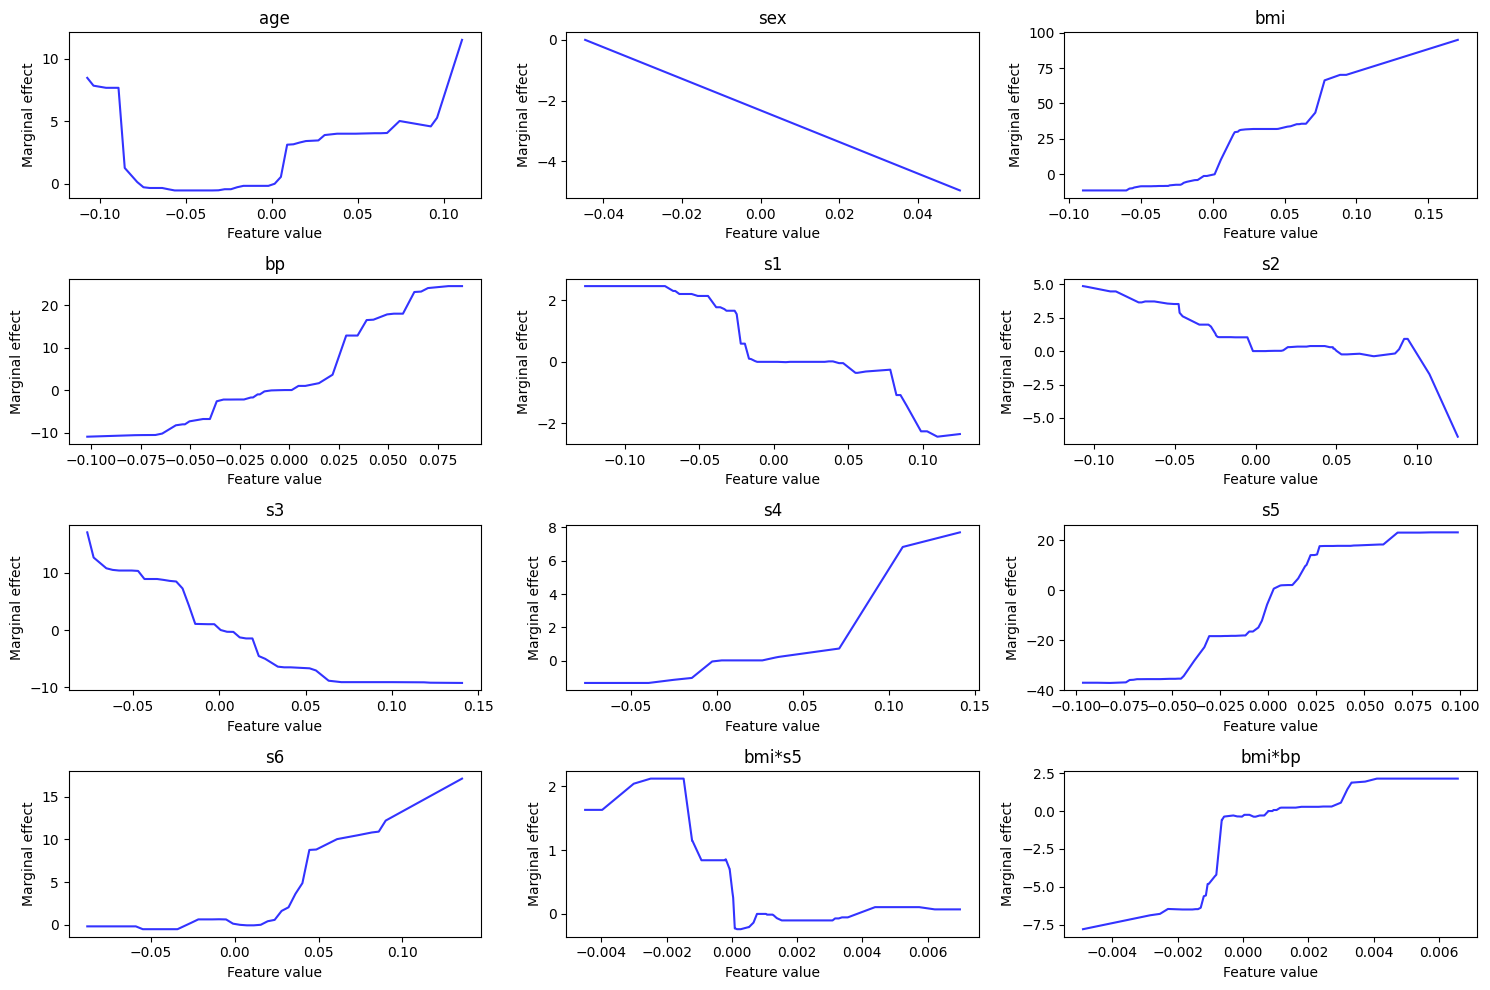


TEAM Model Performance:
MSE: 2658.07
R2:  0.498


In [3]:
"""
Feature engineering based on Random Forest importance analysis,
followed by TEAM (Tree Ensemble Additive Model) explanation.
"""

import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


class TEAM(BaseEstimator, RegressorMixin):
    """
    Tree Ensemble Additive Model (TEAM)
    Original algorithm and implementation.
    All rights reserved for future academic publication.
    """
    def __init__(self, n_estimators=100):
        self.n_estimators = n_estimators
        self.base_estimator = GradientBoostingRegressor(max_depth=1, n_estimators=100)
        self.model = BaggingRegressor(
            estimator=self.base_estimator,
            n_estimators=self.n_estimators
        )
        self.feature_means_ = None
        self.y_mean_ = None

    def fit(self, X, y):
        self.feature_means_ = X.mean(axis=0)
        self.y_mean_ = y.mean()
        self.model.fit(X, y - self.y_mean_)
        return self

    def predict(self, X):
        return self.model.predict(X) + self.y_mean_

    def get_marginal_effect(self, i, X):
        """
        Compute the marginal effect of feature i on the prediction.
        This represents the i-th component of the additive model.

        Parameters:
        -----------
        i : int
            Index of the feature
        X : array-like
            Input data

        Returns:
        --------
        array-like
            Marginal effect of feature i, representing its contribution
            to the final prediction when all other features are at their mean values
        """
        X_mean = np.tile(self.feature_means_, (X.shape[0], 1))

        # Prediction with all features at their means
        all_mean_pred = self.model.predict(X_mean)

        # Replace i-th feature with actual values
        X_i = X_mean.copy()
        X_i[:, i] = X[:, i]

        # Prediction with only i-th feature varying
        pred_i = self.model.predict(X_i)

        return pred_i - all_mean_pred


# Load data
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = list(diabetes.feature_names)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initial Random Forest to find important features
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importance
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)
top_3_idx = sorted_idx[-3:]

# Print feature importances
print("Feature Importances:")
for idx in reversed(sorted_idx):
    print(f"{feature_names[idx]}: {importances[idx]:.4f}")

print("\nTop 3 features:")
for idx in reversed(top_3_idx):
    print(f"{feature_names[idx]}: {importances[idx]:.4f}")

# Create interaction features
X_extended = np.hstack([
    X,
    X[:, top_3_idx[2]].reshape(-1, 1) * X[:, top_3_idx[1]].reshape(-1, 1),
    X[:, top_3_idx[2]].reshape(-1, 1) * X[:, top_3_idx[0]].reshape(-1, 1)
])

# Add new feature names
feature_names.extend([
    f"{feature_names[top_3_idx[2]]}*{feature_names[top_3_idx[1]]}",
    f"{feature_names[top_3_idx[2]]}*{feature_names[top_3_idx[0]]}"
])

# Split extended data
X_train_ext, X_test_ext, y_train, y_test = train_test_split(X_extended, y, test_size=0.2, random_state=42)

# Train TEAM on extended dataset
team = TEAM(n_estimators=100)
team.fit(X_train_ext, y_train)

# Plot marginal effects for all features including interactions
plt.figure(figsize=(15, 10))
n_features = X_extended.shape[1]
n_rows = (n_features + 2) // 3
n_cols = min(3, n_features)

for i, feature_name in enumerate(feature_names):
    plt.subplot(n_rows, n_cols, i+1)

    # Sort points for visualization
    sort_idx = np.argsort(X_test_ext[:, i])
    X_sorted = X_test_ext[sort_idx, i]
    effects = team.get_marginal_effect(i, X_test_ext)
    effects_sorted = effects[sort_idx]

    plt.plot(X_sorted, effects_sorted, 'b-', alpha=0.8)
    plt.title(feature_name)
    plt.xlabel('Feature value')
    plt.ylabel('Marginal effect')

plt.tight_layout()
plt.show()

# Print model performance
y_pred = team.predict(X_test_ext)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nTEAM Model Performance:")
print(f"MSE: {mse:.2f}")
print(f"R2:  {r2:.3f}")